## 1. EDA (Exploratory Data Analysis)

Профиль рынка конкурентов:
                            Source_File                Product_Predicted_Name  \
0             sikahyflex-250-facade.pdf                    PRODUCT DATA SHEET   
1                     2254654_other.pdf  Герметик полиуретановый MASTERFIX-PU   
2  f0d103663006c9a4c3b4a63bb10da91f.pdf       Полиуретановый клей-герметик PU   
3                TDS SANZ PU MASTER.pdf                TDS SANZ PU MASTER.pdf   

   Shore_A  Elongation_Percent  Skin_Time_Min  
0       20               800.0           70.0  
1       30                 NaN            NaN  
2       20               500.0           70.0  
3       40                 NaN            NaN  


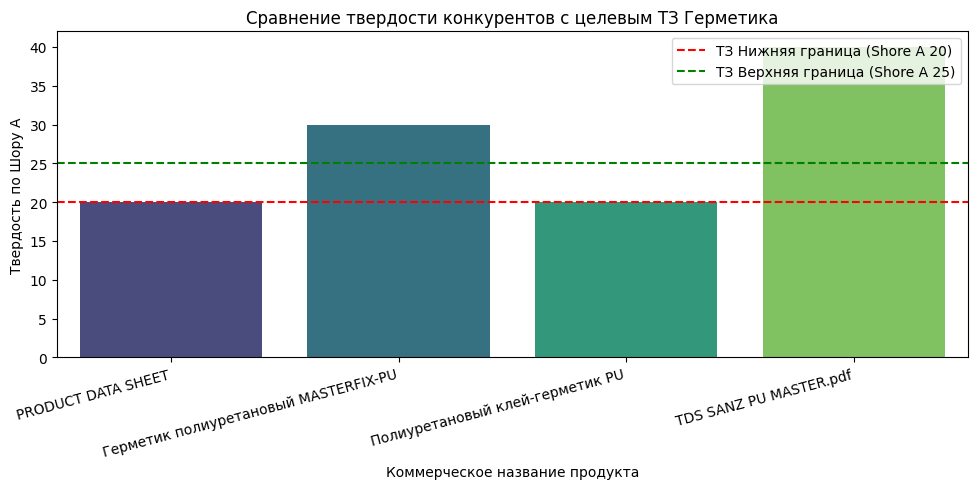

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Загружаем спарсенный датасет
df = pd.read_csv('../data/03_processed/benchmarks_dataset.csv')

# Очищаем дубликаты
df = df.drop_duplicates(subset=['Product_Predicted_Name', 'Shore_A'])

print("Профиль рынка конкурентов:")
print(df)

# 2. Построение графика
plt.figure(figsize=(10, 5))

# Исправлено: регистр палитры (viridis) и добавлен hue для соответствия стандартам v0.14+
sns.barplot(
    x='Product_Predicted_Name', 
    y='Shore_A', 
    data=df, 
    hue='Product_Predicted_Name', 
    palette='viridis', 
    legend=False
)

# Добавляем целевые границы по нашему ТЗ
plt.axhline(y=20, color='r', linestyle='--', linewidth=1.5, label='ТЗ Нижняя граница (Shore A 20)')
plt.axhline(y=25, color='g', linestyle='--', linewidth=1.5, label='ТЗ Верхняя граница (Shore A 25)')

plt.title('Сравнение твердости конкурентов с целевым ТЗ Герметика')
plt.ylabel('Твердость по Шору А')
plt.xlabel('Коммерческое название продукта')
plt.xticks(rotation=15, ha='right')
plt.legend(loc='upper right')
plt.tight_layout()

plt.show()

## 2. Запуск симуляции пространства рецептур

In [4]:
import sys
import os
import pandas as pd
import numpy as np

# Добавляем путь к src в sys.path, чтобы импортировать наш калькулятор
sys.path.append(os.path.abspath('../src'))
from features.pu_calculator import PolyurethaneCalculator

# Задаем константы для сырья
MDI_MW = 250.25  # Молекулярная масса 4,4'-MDI

# Генерируем пространство параметров для симуляции
polyol_options = [2000, 3000, 4000]  # Молекулярные массы промышленных ППГ-диолов
nco_indices = np.linspace(1.5, 2.2, 8)  # Шаг изменения NCO/OH индекса от 1.5 до 2.2

results = []

for mw in polyol_options:
    for index in nco_indices:
        calc_res = PolyurethaneCalculator.calculate_formulation(
            polyol_mw=mw,
            polyol_func=2.0,  # работаем с диолами для высокой эластичности
            diisocyanate_mw=MDI_MW,
            nco_index=index
        )
        calc_res["Polyol_Mw"] = mw
        results.append(calc_res)

# Превращаем результаты симуляции в DataFrame
sim_df = pd.DataFrame(results)

# Выведем срез данных, например для длинного диола ППГ-4000
print("Варианты синтеза форполимера на основе ППГ-4000 (на 100г полиола):")
print(sim_df[sim_df['Polyol_Mw'] == 4000][['NCO_OH_Index', 'Isocyanate_Mass_g', 'Theoretical_Free_NCO_Percent']])

Варианты синтеза форполимера на основе ППГ-4000 (на 100г полиола):
    NCO_OH_Index  Isocyanate_Mass_g  Theoretical_Free_NCO_Percent
16           1.5               9.38                          0.96
17           1.6              10.01                          1.15
18           1.7              10.64                          1.33
19           1.8              11.26                          1.51
20           1.9              11.89                          1.69
21           2.0              12.51                          1.87
22           2.1              13.14                          2.04
23           2.2              13.76                          2.22
